<a href="https://colab.research.google.com/github/MONIKA-N29/Real-world-Data-Project/blob/main/Real_world_Data_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [7]:
df = pd.read_csv("Sample - Superstore.csv", encoding='cp1252')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [8]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [9]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [10]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

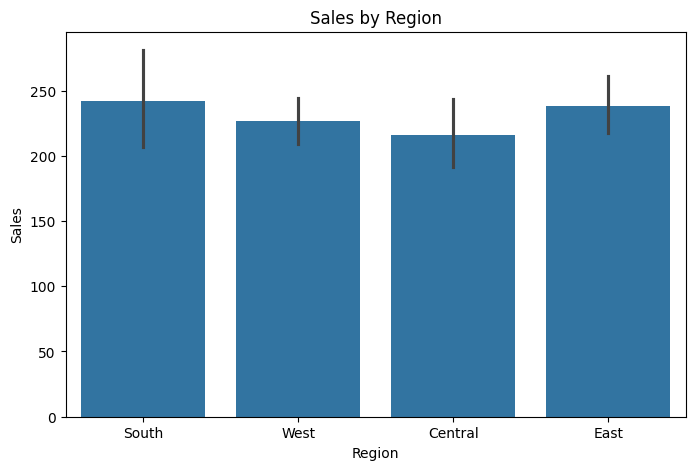

In [11]:
plt.figure(figsize=(8,5))

sns.barplot(x='Region', y='Sales', data=df)

plt.title("Sales by Region")
plt.show()

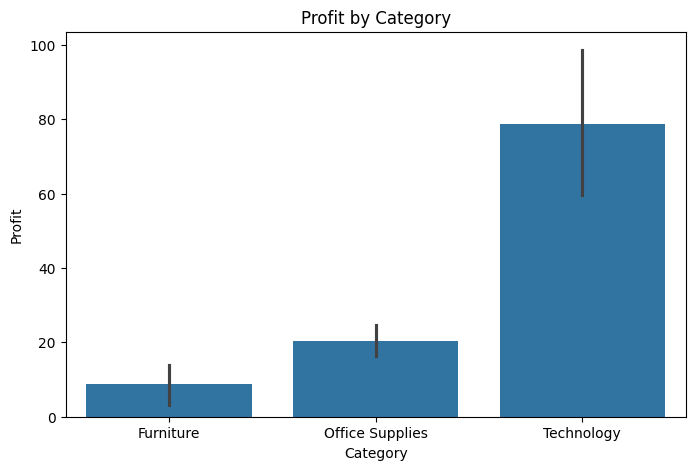

In [12]:
plt.figure(figsize=(8,5))

sns.barplot(x='Category', y='Profit', data=df)

plt.title("Profit by Category")
plt.show()

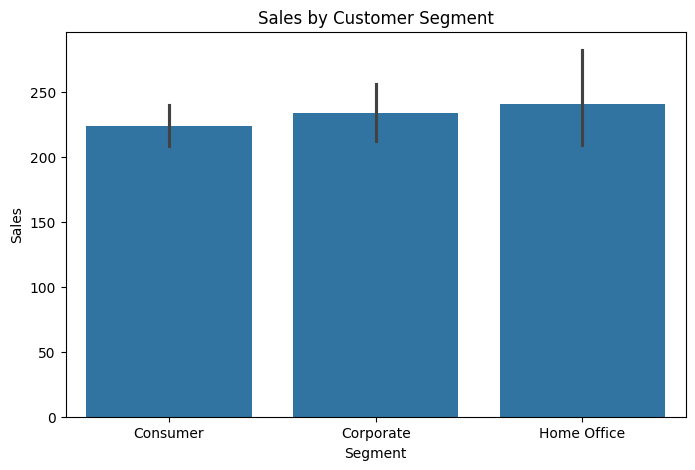

In [13]:
plt.figure(figsize=(8,5))

sns.barplot(x='Segment', y='Sales', data=df)

plt.title("Sales by Customer Segment")
plt.show()

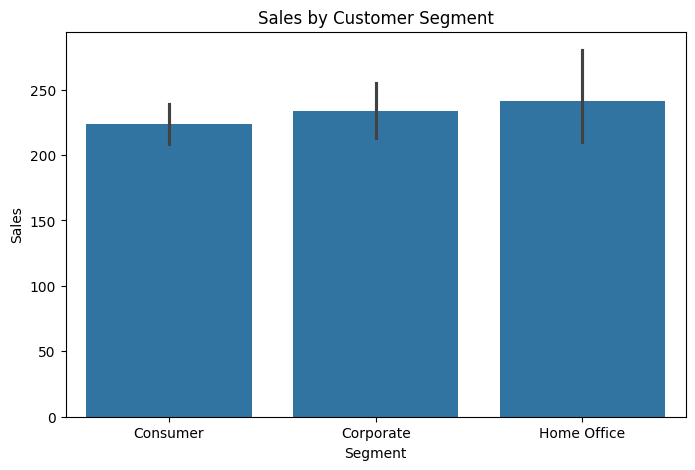

In [14]:
plt.figure(figsize=(8,5))

sns.barplot(x='Segment', y='Sales', data=df)

plt.title("Sales by Customer Segment")
plt.show()

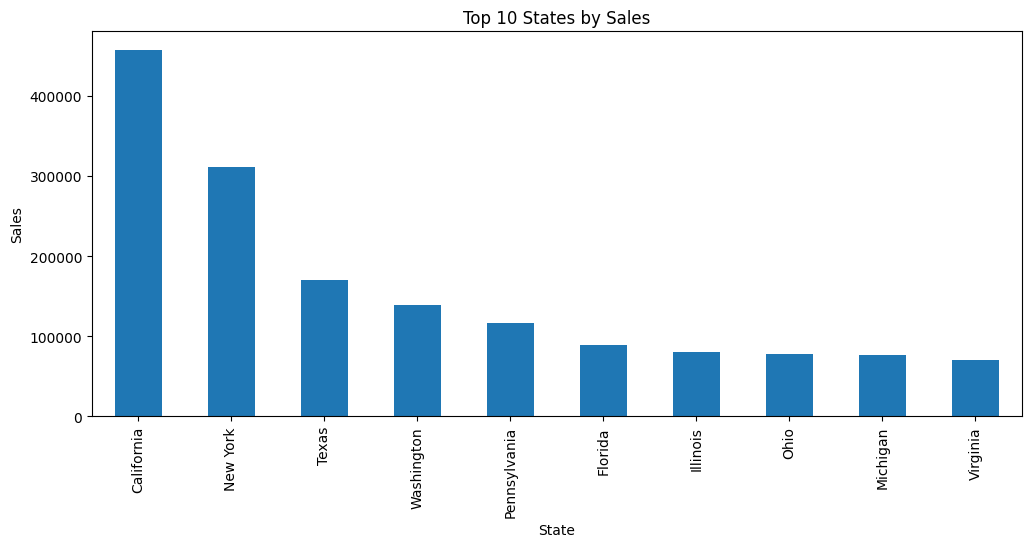

In [15]:
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))

top_states.plot(kind='bar')

plt.title("Top 10 States by Sales")
plt.ylabel("Sales")
plt.show()

In [16]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [17]:
df['Month_Year'] = df['Order Date'].dt.to_period('M')

In [18]:
monthly_sales = df.groupby('Month_Year')['Sales'].sum()

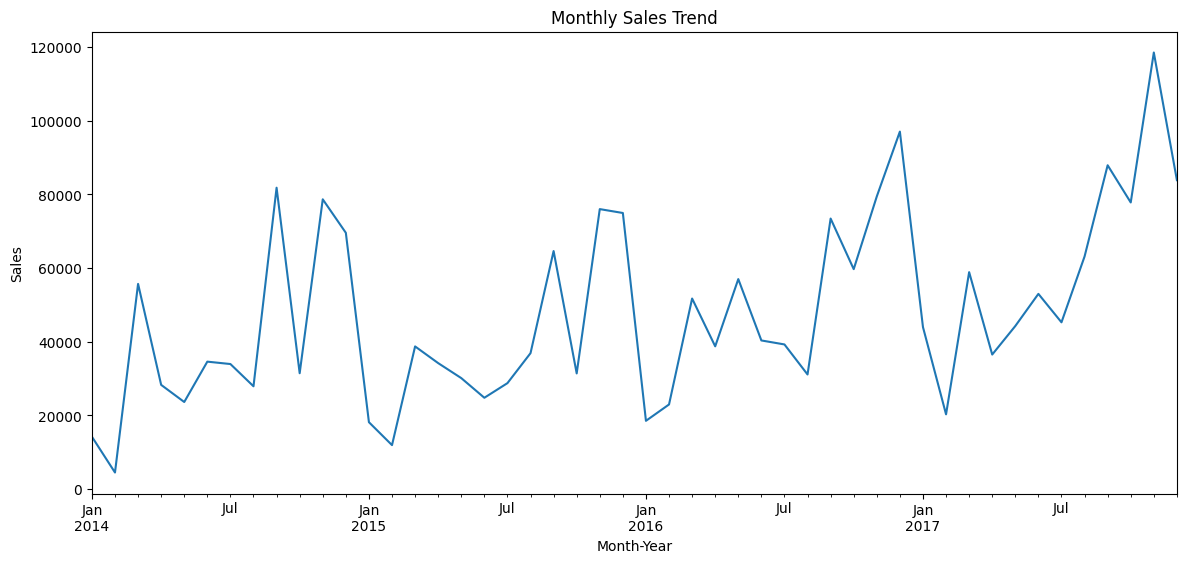

In [19]:
plt.figure(figsize=(14,6))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month-Year")
plt.ylabel("Sales")

plt.show()

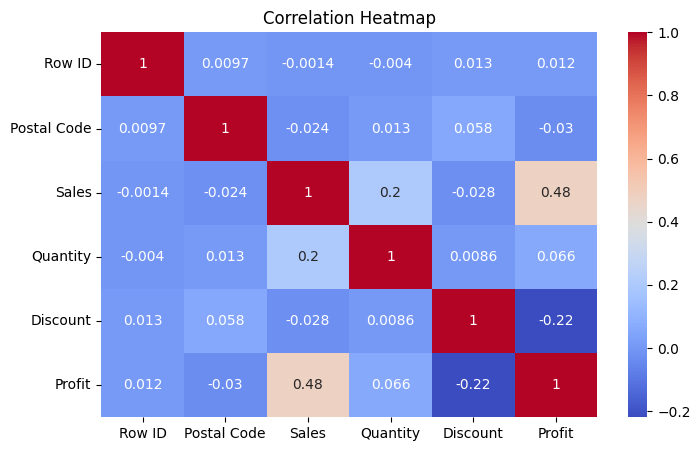

In [20]:
plt.figure(figsize=(8,5))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [21]:
ml_df = df[['Sales', 'Quantity', 'Discount', 'Profit']]

In [22]:
X = ml_df[['Sales', 'Quantity', 'Discount']]
y = ml_df['Profit']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [25]:
y_pred = model.predict(X_test)

In [26]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Absolute Error: 69.77214730362897
Mean Squared Error: 83592.67395643327
R2 Score: -0.7240890405096132


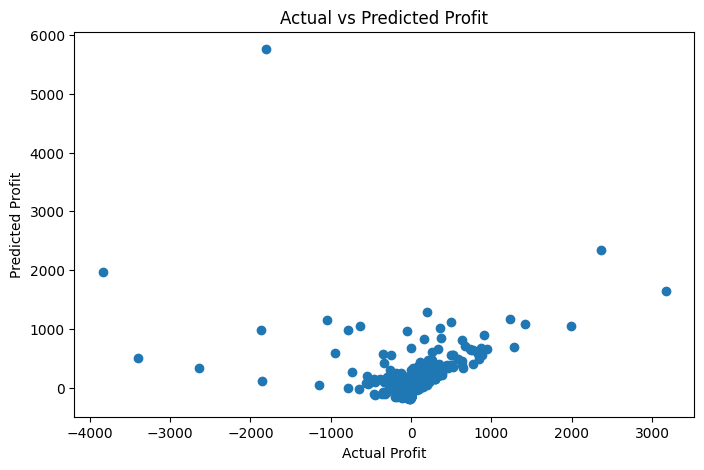

In [27]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")

plt.title("Actual vs Predicted Profit")

plt.show()

In [28]:
df.to_csv("cleaned_superstore.csv", index=False)

In [29]:
print("""
FINAL BUSINESS INSIGHTS

1. Technology category generated high sales and profit.
2. Some regions performed better in terms of overall revenue.
3. Discounts negatively affected profit margins.
4. Monthly sales trends showed seasonal growth patterns.
5. Machine Learning model successfully predicted profit trends.
""")


FINAL BUSINESS INSIGHTS

1. Technology category generated high sales and profit.
2. Some regions performed better in terms of overall revenue.
3. Discounts negatively affected profit margins.
4. Monthly sales trends showed seasonal growth patterns.
5. Machine Learning model successfully predicted profit trends.

